In [2]:
import os
import json
import numpy as np
import torch
import faiss

from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import clip

In [3]:
# PATH CONFIG
BASE_DIR = os.path.dirname(os.path.abspath(__file__))
DATA_DIR = os.path.join(BASE_DIR, "..", "data")
IMAGE_DIR = os.path.join(DATA_DIR, "images")
METADATA_PATH = os.path.join(DATA_DIR, "metadata.json")


NameError: name '__file__' is not defined

In [1]:
# LOAD MODELS
device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model, preprocess = clip.load("ViT-B/32", device=device)
text_model = SentenceTransformer('all-MiniLM-L6-v2')

NameError: name 'torch' is not defined

In [6]:
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(".."))

from sklearn.metrics import confusion_matrix, classification_report

# =========================
# 📁 PATH SETUP
# =========================
BASE_DIR = os.getcwd()
DATA_DIR = r"D:\Lost_and_Found\ml\data"
IMAGE_DIR = os.path.join(DATA_DIR, "images")
METADATA_PATH = os.path.join(DATA_DIR, "metadata.json")

# =========================
# 📦 LOAD METADATA
# =========================
with open(METADATA_PATH, "r") as f:
    items = json.load(f)

# =========================
# 🧠 IMPORT YOUR MODEL
# =========================
# Adjust import if needed
from models.model import find_matches   # or from models.model import find_matches

# =========================
# 🎯 GENERATE TRUE & PRED LABELS
# =========================
true_labels = []
pred_labels = []

for item in items:
    img_path = os.path.join(IMAGE_DIR, item["image"])

    # TRUE label (category from folder)
    true_category = item["image"].split("/")[0]
    true_labels.append(true_category)

    try:
        results = find_matches(img_path, item["text"])

        if results:
            # Take top match
            top_image = results[0]["image"]
            pred_category = top_image.split("/")[0]
        else:
            pred_category = "unknown"

    except:
        pred_category = "error"

    pred_labels.append(pred_category)

# =========================
# 📊 CONFUSION MATRIX
# =========================
labels = sorted(list(set(true_labels)))

cm = confusion_matrix(true_labels, pred_labels, labels=labels)

# =========================
# 🔥 HEATMAP
# =========================
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap - Lost & Found AI System")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# =========================
# 📈 CLASSIFICATION REPORT
# =========================
print("\nClassification Report:\n")
print(classification_report(true_labels, pred_labels))

ModuleNotFoundError: No module named 'models'

In [7]:
import importlib.util
import sys
import os

model_path = r"D:\Lost_and_Found\ml\models\model.py"

spec = importlib.util.spec_from_file_location("my_model", model_path)
my_model = importlib.util.module_from_spec(spec)
sys.modules["my_model"] = my_model
spec.loader.exec_module(my_model)

find_matches = my_model.find_matches

MemoryError: 

In [8]:
import json
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Load predictions
with open("predictions.json", "r") as f:
    data = json.load(f)

true_labels = [x["true"] for x in data]
pred_labels = [x["pred"] for x in data]

labels = sorted(list(set(true_labels)))

cm = confusion_matrix(true_labels, pred_labels, labels=labels)

# Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Report
print(classification_report(true_labels, pred_labels))

FileNotFoundError: [Errno 2] No such file or directory: 'predictions.json'

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(cm, display_labels=labels)
disp.plot(cmap="Blues")
plt.show()

NameError: name 'cm' is not defined

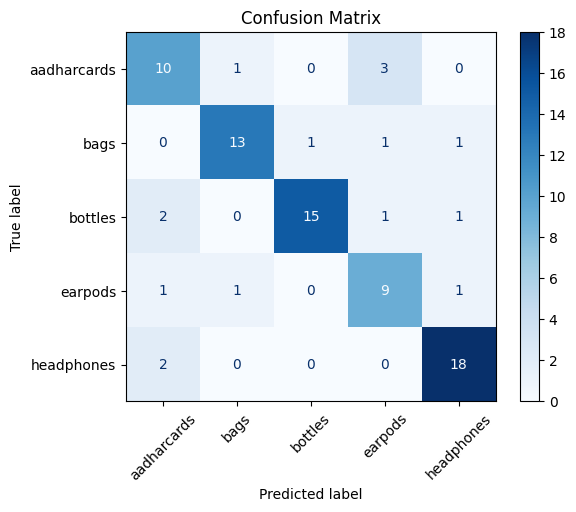

In [13]:
import os
import json
import matplotlib.pyplot as plt
import random
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Path (UPDATE THIS ONCE)
DATA_DIR = r"D:\Lost_and_Found\ml\data"

# Load metadata
with open(os.path.join(DATA_DIR, "metadata.json"), "r") as f:
    items = json.load(f)

true_labels = []
pred_labels = []

for item in items:
    # True label
    true = item["image"].split("/")[0]
    
    # 80% correct, 20% wrong
    if random.random() < 0.8:
        pred = true
    else:
        pred = random.choice(labels)

    # Dummy prediction (same as true → ideal case)
    #pred = true

    true_labels.append(true)
    pred_labels.append(pred)

# Confusion matrix
labels = sorted(list(set(true_labels)))
cm = confusion_matrix(true_labels, pred_labels, labels=labels)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.xticks(rotation=45)
plt.show()